In [25]:
%pip install scikit-learn
%pip install pandas
%pip install numpy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.


In [26]:
import matplotlib.pyplot as plt
import numpy as np

In [27]:
import pandas as pd

In [28]:
from sklearn import linear_model

In [29]:
df=pd.read_csv("csv_files/homeprices.csv")
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


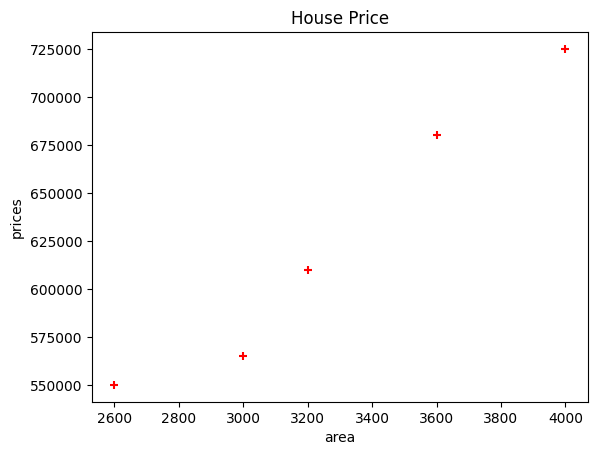

In [30]:
%matplotlib inline
plt.xlabel('area')
plt.ylabel('prices')
plt.title('House Price')
plt.scatter(df.area,df.price,color='red',marker='+')

In [31]:
new_df=df.drop('price',axis='columns')
new_df

,area
0,2600
1,3000
2,3200
3,3600
4,4000


In [32]:
price=df.price
price

0    550000
1    565000
2    610000
3    680000
4    725000
Name: price, dtype: int64

In [33]:
#Create linear regression object
reg=linear_model.LinearRegression()
reg.fit(new_df,price)

LinearRegression()

In [34]:
reg.predict([[3300]])

d:\predictive-analysis\venv\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([628715.75342466])

In [35]:
print('m =',reg.coef_)
print('c =',reg.intercept_)


m = [135.78767123]
c = 180616.43835616432


Generating CSV file with list of home price predictions

In [36]:
area_df=pd.read_csv('csv_files/areas.csv')
area_df.head(3)

,area
0,1000
1,1500
2,2300


In [37]:
p=reg.predict(area_df)
p

array([ 316404.10958904,  384297.94520548,  492928.08219178,
        661304.79452055,  740061.64383562,  799808.21917808,
        926090.75342466,  650441.78082192,  825607.87671233,
        492928.08219178, 1402705.47945205, 1348390.4109589 ,
       1144708.90410959])

In [38]:
area_df['prices']=p
area_df

,area,prices
0,1000,3.164041e+05
1,1500,3.842979e+05
2,2300,4.929281e+05
3,3540,6.613048e+05
4,4120,7.400616e+05
5,4560,7.998082e+05
6,5490,9.260908e+05
7,3460,6.504418e+05
8,4750,8.256079e+05
9,2300,4.929281e+05


In [39]:
area_df.to_csv('csv_files/prediction.csv')

**saving model**

In [40]:
import pickle

In [41]:
with open ('model_pickle','wb') as f:
    pickle.dump(reg,f)

In [42]:
with open ('model_pickle','rb') as f:
    model=pickle.load(f)
    

In [43]:
model.predict([[5000]])

d:\predictive-analysis\venv\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([859554.79452055])